# Chronos_Bolt_Tiny

In [284]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from chronos import BaseChronosPipeline
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

In [285]:
# ── Output directory ──────────────────────────────────────────
img_path = "../outputs/chronos_bolt_tiny/"
pathlib_path = Path(img_path)
if not pathlib_path.exists():
    pathlib_path.mkdir(parents=True, exist_ok=True)

In [286]:
# ── Reproducibility ────────────────────────────────────────────
np.random.seed(42)
torch.manual_seed(42)

In [287]:
# ── Load model ─────────────────────────────────────────────────
pipeline = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-bolt-tiny",
    device_map="cpu",
)
model = pipeline.model
print("Model type:", type(model))

Model type: <class 'chronos.chronos_bolt.ChronosBoltModelForForecasting'>


In [288]:
print(dir(pipeline))

['__annotations__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_prepare_and_validate_context', 'default_context_length', 'dtypes', 'embed', 'forecast_type', 'from_pretrained', 'inner_model', 'model', 'model_context_length', 'model_prediction_length', 'predict', 'predict_df', 'predict_fev', 'predict_quantiles', 'quantiles']


In [289]:
import torch
import pprint

def inspect_chronos_pipeline(pipeline):

    print("\n================ TOP-LEVEL ATTRIBUTES ================\n")
    attrs = [a for a in dir(pipeline) if not a.startswith("_")]
    print(attrs)

    print("\n================ KEY ATTRIBUTES (IF PRESENT) ================\n")
    keys = [
        "model_prediction_length",
        "model_context_length",
        "forecast_type",
        "inner_model",
        "model",
        "quantiles",
    ]

    for k in keys:
        if hasattr(pipeline, k):
            print(f"{k}: {getattr(pipeline, k)}")
        else:
            print(f"{k}: NOT FOUND")

    print("\n================ INNER MODEL INFO ================\n")
    if hasattr(pipeline, "inner_model"):
        im = pipeline.inner_model
        print("inner_model type:", type(im))

        # try config
        if hasattr(im, "config"):
            print("\ninner_model.config:")
            pprint.pprint(im.config)

        # try attributes of inner model
        print("\ninner_model attributes:")
        print([a for a in dir(im) if not a.startswith("_")][:50])
    else:
        print("No inner_model")

    print("\n================ PREDICT METHOD SIGNATURE ================\n")
    try:
        import inspect
        print(inspect.signature(pipeline.predict))
    except Exception as e:
        print("Could not inspect predict:", e)

    print("\n================ DEVICE INFO ================\n")
    try:
        p = next(pipeline.inner_model.parameters())
        print("device:", p.device)
        print("dtype:", p.dtype)
    except Exception:
        print("No torch parameters found")

    print("\n================ QUICK SANITY CHECK ================\n")
    try:
        print("model_prediction_length:", getattr(pipeline, "model_prediction_length", None))
        print("context_length:", getattr(pipeline, "model_context_length", None))
    except Exception as e:
        print("error:", e)

inspect_chronos_pipeline(pipeline)


================ TOP-LEVEL ATTRIBUTES ================

['default_context_length', 'dtypes', 'embed', 'forecast_type', 'from_pretrained', 'inner_model', 'model', 'model_context_length', 'model_prediction_length', 'predict', 'predict_df', 'predict_fev', 'predict_quantiles', 'quantiles']

================ KEY ATTRIBUTES (IF PRESENT) ================

model_prediction_length: 64
model_context_length: 2048
forecast_type: ForecastType.QUANTILES
inner_model: ChronosBoltModelForForecasting(
  (shared): Embedding(2, 256)
  (input_patch_embedding): ResidualBlock(
    (dropout): Dropout(p=0.1, inplace=False)
    (hidden_layer): Linear(in_features=32, out_features=1024, bias=True)
    (act): ReLU()
    (output_layer): Linear(in_features=1024, out_features=256, bias=True)
    (residual_layer): Linear(in_features=32, out_features=256, bias=True)
  )
  (patch): Patch()
  (instance_norm): InstanceNorm()
  (encoder): T5Stack(
    (embed_tokens): Embedding(2, 256)
    (block): ModuleList(
      (0): T

## Model

In [290]:
model = pipeline.model

print(type(model))

<class 'chronos.chronos_bolt.ChronosBoltModelForForecasting'>


In [291]:
print(pipeline.model.config)

T5Config {
  "architectures": [
    "ChronosBoltModelForForecasting"
  ],
  "chronos_config": {
    "context_length": 2048,
    "input_patch_size": 16,
    "input_patch_stride": 16,
    "prediction_length": 64,
    "quantiles": [
      0.1,
      0.2,
      0.3,
      0.4,
      0.5,
      0.6,
      0.7,
      0.8,
      0.9
    ],
    "use_reg_token": true
  },
  "chronos_pipeline_class": "ChronosBoltPipeline",
  "classifier_dropout": 0.0,
  "d_ff": 1024,
  "d_kv": 64,
  "d_model": 256,
  "decoder_start_token_id": 0,
  "dense_act_fn": "relu",
  "dropout_rate": 0.1,
  "dtype": "float32",
  "eos_token_id": 1,
  "feed_forward_proj": "relu",
  "initializer_factor": 0.05,
  "is_encoder_decoder": true,
  "is_gated_act": false,
  "layer_norm_epsilon": 1e-06,
  "model_type": "t5",
  "n_positions": 512,
  "num_decoder_layers": 4,
  "num_heads": 4,
  "num_layers": 4,
  "pad_token_id": 0,
  "reg_token_id": 1,
  "relative_attention_max_distance": 128,
  "relative_attention_num_buckets": 32,
  "t

### Parameter Variation

In [292]:
# 1. Valori attuali di P e S
DEFAULT_PATCH_SIZE = pipeline.model.patch.patch_size
print("DEFAULT_PATCH_SIZE:", DEFAULT_PATCH_SIZE)
DEFAULT_STRIDE = pipeline.model.patch.patch_stride
print("DEFAULT_STRIDE:", DEFAULT_STRIDE)

# se S == P non c'è overlap, se S < P c'è overlap e se S > P ci sono buchi tra le patch

DEFAULT_PATCH_SIZE: 16
DEFAULT_STRIDE: 16


In [293]:
# 2. Tutti gli attributi dell'oggetto Patch
print(vars(pipeline.model.patch))

{'training': False, '_parameters': {}, '_buffers': {}, '_non_persistent_buffers_set': set(), '_backward_pre_hooks': OrderedDict(), '_backward_hooks': OrderedDict(), '_is_full_backward_hook': None, '_forward_hooks': OrderedDict(), '_forward_hooks_with_kwargs': OrderedDict(), '_forward_hooks_always_called': OrderedDict(), '_forward_pre_hooks': OrderedDict(), '_forward_pre_hooks_with_kwargs': OrderedDict(), '_state_dict_hooks': OrderedDict(), '_state_dict_pre_hooks': OrderedDict(), '_load_state_dict_pre_hooks': OrderedDict(), '_load_state_dict_post_hooks': OrderedDict(), '_modules': {}, 'patch_size': 16, 'patch_stride': 16, '_is_hf_initialized': True}


In [294]:
# 3. Il config completo
print(pipeline.model.config.chronos_config)

{'context_length': 2048, 'input_patch_size': 16, 'input_patch_stride': 16, 'prediction_length': 64, 'quantiles': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9], 'use_reg_token': True}


In [295]:
# 4. Source completo della classe Patch (init + forward)
import inspect
print(inspect.getsource(pipeline.model.patch.__class__))
# It is useful for understanding how the patching works and where the stride is applied.
# Focus on the forward method to see how the input is transformed into patches and how the stride is applied.

class Patch(nn.Module):
    def __init__(self, patch_size: int, patch_stride: int) -> None:
        super().__init__()
        self.patch_size = patch_size
        self.patch_stride = patch_stride

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        length = x.shape[-1]

        if length % self.patch_size != 0:
            padding_size = (
                *x.shape[:-1],
                self.patch_size - (length % self.patch_size),
            )
            padding = torch.full(size=padding_size, fill_value=torch.nan, dtype=x.dtype, device=x.device)
            x = torch.concat((padding, x), dim=-1)

        x = x.unfold(dimension=-1, size=self.patch_size, step=self.patch_stride)
        return x



La classe Patch non ha pesi propri 
- S cambiabile: patch_stride è solo il step di unfold → nessun peso coinvolto
- P non cambiabile: patch_size è la size di unfold → produce patch di dimensione diversa → si rompe input_patch_embedding che ha pesi fissi in_features=32=2*16

In [296]:
# PATCH VARIATION TEST
PATCH_SIZE = 8

pipeline.model.patch.patch_size = PATCH_SIZE
pipeline.model.patch.patch_stride = DEFAULT_STRIDE

signal = np.sin(2 * np.pi * (1/16) * np.arange(300))
ctx = torch.tensor(signal[:200], dtype=torch.float32).unsqueeze(0)

try:
    pred = pipeline.predict(ctx, prediction_length=24)
    print("-----WORKS-----")
except Exception as e:
    print(f"-----CRASHES-----: {e}")

-----CRASHES-----: mat1 and mat2 shapes cannot be multiplied (13x16 and 32x1024)


In [297]:
# STRIDE VARIATION TEST
STRIDE = 8

pipeline.model.patch.patch_stride = STRIDE
pipeline.model.patch.patch_size = DEFAULT_PATCH_SIZE

signal = np.sin(2 * np.pi * (1/16) * np.arange(300))
ctx = torch.tensor(signal[:200], dtype=torch.float32).unsqueeze(0)

try:
    pred = pipeline.predict(ctx, prediction_length=24)
    print("-----WORKS-----")
except Exception as e:
    print(f"-----CRASHES-----: {e}")


-----WORKS-----


In [298]:
print(pipeline.model.input_patch_embedding)
# cerca la dimensione di input — sarà 2*16 = 32

ResidualBlock(
  (dropout): Dropout(p=0.1, inplace=False)
  (hidden_layer): Linear(in_features=32, out_features=1024, bias=True)
  (act): ReLU()
  (output_layer): Linear(in_features=1024, out_features=256, bias=True)
  (residual_layer): Linear(in_features=32, out_features=256, bias=True)
)


### Layers

In [299]:
pre_transformer_modules = []
encoder_modules = []
decoder_modules = []
post_transformer_modules = []

modules = []
for name, module in model.named_modules():
    modules.append((name, module))
    print(name, type(module))


 <class 'chronos.chronos_bolt.ChronosBoltModelForForecasting'>
shared <class 'torch.nn.modules.sparse.Embedding'>
input_patch_embedding <class 'chronos.chronos_bolt.ResidualBlock'>
input_patch_embedding.dropout <class 'torch.nn.modules.dropout.Dropout'>
input_patch_embedding.hidden_layer <class 'torch.nn.modules.linear.Linear'>
input_patch_embedding.act <class 'torch.nn.modules.activation.ReLU'>
input_patch_embedding.output_layer <class 'torch.nn.modules.linear.Linear'>
input_patch_embedding.residual_layer <class 'torch.nn.modules.linear.Linear'>
patch <class 'chronos.chronos_bolt.Patch'>
instance_norm <class 'chronos.chronos_bolt.InstanceNorm'>
encoder <class 'transformers.models.t5.modeling_t5.T5Stack'>
encoder.block <class 'torch.nn.modules.container.ModuleList'>
encoder.block.0 <class 'transformers.models.t5.modeling_t5.T5Block'>
encoder.block.0.layer <class 'torch.nn.modules.container.ModuleList'>
encoder.block.0.layer.0 <class 'transformers.models.t5.modeling_t5.T5LayerSelfAttent

In [300]:
for name, module in modules:
    if "encoder" not in name:
        pre_transformer_modules.append((name, module))
        modules.remove((name, module))
    else:
        break

i = 0
for name, module in pre_transformer_modules:
    if i == 0:
        print(f"Pre-transformer modules: {type(module)}")
    else:
        print(f"{i}: {name}: {type(module)}")
    i += 1

Pre-transformer modules: <class 'chronos.chronos_bolt.ChronosBoltModelForForecasting'>
1: input_patch_embedding: <class 'chronos.chronos_bolt.ResidualBlock'>
2: input_patch_embedding.hidden_layer: <class 'torch.nn.modules.linear.Linear'>
3: input_patch_embedding.output_layer: <class 'torch.nn.modules.linear.Linear'>
4: patch: <class 'chronos.chronos_bolt.Patch'>


In [301]:
for name, module in modules:
    if "encoder" in name and "decoder" not in name:
        encoder_modules.append((name, module))
        modules.remove((name, module))
        
i = 0
for name, module in encoder_modules:
    if i == 0:
        print(f"Encoder modules: {type(module)}")
    else:
        print(f"{i}: {name}: {type(module)}")
    i += 1

Encoder modules: <class 'transformers.models.t5.modeling_t5.T5Stack'>
1: encoder.block.0: <class 'transformers.models.t5.modeling_t5.T5Block'>
2: encoder.block.0.layer.0: <class 'transformers.models.t5.modeling_t5.T5LayerSelfAttention'>
3: encoder.block.0.layer.0.SelfAttention.q: <class 'torch.nn.modules.linear.Linear'>
4: encoder.block.0.layer.0.SelfAttention.v: <class 'torch.nn.modules.linear.Linear'>
5: encoder.block.0.layer.0.SelfAttention.relative_attention_bias: <class 'torch.nn.modules.sparse.Embedding'>
6: encoder.block.0.layer.0.dropout: <class 'torch.nn.modules.dropout.Dropout'>
7: encoder.block.0.layer.1.DenseReluDense: <class 'transformers.models.t5.modeling_t5.T5DenseActDense'>
8: encoder.block.0.layer.1.DenseReluDense.wo: <class 'torch.nn.modules.linear.Linear'>
9: encoder.block.0.layer.1.DenseReluDense.act: <class 'torch.nn.modules.activation.ReLU'>
10: encoder.block.0.layer.1.dropout: <class 'torch.nn.modules.dropout.Dropout'>
11: encoder.block.1.layer: <class 'torch.nn

In [302]:
for name, module in modules:
    if "decoder" in name:
        decoder_modules.append((name, module))
        modules.remove((name, module))

i = 0
for name, module in decoder_modules:
    if i == 0:
        print(f"Decoder modules: {type(module)}")
    else:
        print(f"{i}: {name}: {type(module)}")
    i += 1

Decoder modules: <class 'transformers.models.t5.modeling_t5.T5Stack'>
1: decoder.block.0: <class 'transformers.models.t5.modeling_t5.T5Block'>
2: decoder.block.0.layer.0: <class 'transformers.models.t5.modeling_t5.T5LayerSelfAttention'>
3: decoder.block.0.layer.0.SelfAttention.q: <class 'torch.nn.modules.linear.Linear'>
4: decoder.block.0.layer.0.SelfAttention.v: <class 'torch.nn.modules.linear.Linear'>
5: decoder.block.0.layer.0.SelfAttention.relative_attention_bias: <class 'torch.nn.modules.sparse.Embedding'>
6: decoder.block.0.layer.0.dropout: <class 'torch.nn.modules.dropout.Dropout'>
7: decoder.block.0.layer.1.EncDecAttention: <class 'transformers.models.t5.modeling_t5.T5Attention'>
8: decoder.block.0.layer.1.EncDecAttention.k: <class 'torch.nn.modules.linear.Linear'>
9: decoder.block.0.layer.1.EncDecAttention.o: <class 'torch.nn.modules.linear.Linear'>
10: decoder.block.0.layer.1.dropout: <class 'torch.nn.modules.dropout.Dropout'>
11: decoder.block.0.layer.2.DenseReluDense: <clas

In [303]:
for name, module in modules[20:]:
    if "encoder" not in name and "decoder" not in name:
        post_transformer_modules.append((name, module))

i = 0
for name, module in post_transformer_modules:
    if i == 0:
        print(f"Post-transformer modules: {type(module)}")
    else:
        print(f"{i}: {name}: {type(module)}")
    i += 1

Post-transformer modules: <class 'chronos.chronos_bolt.ResidualBlock'>
1: output_patch_embedding.dropout: <class 'torch.nn.modules.dropout.Dropout'>
2: output_patch_embedding.hidden_layer: <class 'torch.nn.modules.linear.Linear'>
3: output_patch_embedding.act: <class 'torch.nn.modules.activation.ReLU'>
4: output_patch_embedding.output_layer: <class 'torch.nn.modules.linear.Linear'>
5: output_patch_embedding.residual_layer: <class 'torch.nn.modules.linear.Linear'>


## Embeddings Learning

### Hooks

In [304]:
# ── Utilities ──────────────────────────────────────────────────

captured = {}
hooks    = []

def to_cpu(x):
    if torch.is_tensor(x):
        return x.detach().cpu()
    elif isinstance(x, tuple):
        return tuple(to_cpu(item) for item in x)
    return x

def remove_hooks():
    for h in hooks:
        h.remove()
    hooks.clear()
    print(f"Removed all hooks. captured keys: {list(captured.keys())}")

#### 1. Pre-Encoder Hooks

In [305]:
# 1. Instance normalisation output
def norm_hook(module, inputs, outputs):
    captured["normalized"] = to_cpu(outputs)
hooks.append(model.instance_norm.register_forward_hook(norm_hook))

# 2. Raw patches (batch, num_patches, patch_size)
def patch_hook(module, inputs, outputs):
    captured["patch"] = to_cpu(outputs)
hooks.append(model.patch.register_forward_hook(patch_hook))

# 3a. Input to the embedding NN (= concat of patch + mask → shape (B, N_patches, 2·P))
def embedding_input_hook(module, inputs):
    if inputs:
        captured["embedding_input"] = to_cpu(inputs[0])
hooks.append(model.input_patch_embedding.hidden_layer.register_forward_pre_hook(embedding_input_hook))

# 3b. Hidden layer output (B, N_patches, 2048)
def hidden_hook(module, inputs, outputs):
    captured["hidden"] = to_cpu(outputs)
hooks.append(model.input_patch_embedding.hidden_layer.register_forward_hook(hidden_hook))

# 3c. ReLU activations (B, N_patches, 2048)
def relu_hook(module, inputs, outputs):
    captured["relu"] = to_cpu(outputs)
hooks.append(model.input_patch_embedding.act.register_forward_hook(relu_hook))

# 3d. Output linear (B, N_patches, d_model=256)
def output_hook(module, inputs, outputs):
    captured["output_linear"] = to_cpu(outputs)
hooks.append(model.input_patch_embedding.output_layer.register_forward_hook(output_hook))

# 3e. Residual connection (B, N_patches, d_model=256)
def residual_hook(module, inputs, outputs):
    captured["residual"] = to_cpu(outputs)
hooks.append(model.input_patch_embedding.residual_layer.register_forward_hook(residual_hook))

# 3f. Final encoder-input embeddings (B, N_patches, d_model=256)
def final_embedding_hook(module, inputs, outputs):
    captured["final_embedding"] = to_cpu(outputs)
hooks.append(model.input_patch_embedding.register_forward_hook(final_embedding_hook))

print(f"Pre-encoder hooks registered: {len(hooks)}")

Pre-encoder hooks registered: 8


#### 2. Encoder Hooks

In [306]:
# Encoder blocks 0-3: output hidden states (B, N_patches [+REG], d_model)
def make_encoder_hook(layer_idx):
    def hook(module, inputs, outputs):
        hs = outputs[0] if isinstance(outputs, tuple) else outputs
        captured[f"encoder_block_{layer_idx}"] = hs.detach().cpu()
    return hook

for i, block in enumerate(model.encoder.block):
    hooks.append(block.register_forward_hook(make_encoder_hook(i)))

# Encoder final layer norm
def encoder_output_hook(module, inputs, outputs):
    captured["encoder_output_layer"] = to_cpu(outputs)
hooks.append(model.encoder.final_layer_norm.register_forward_hook(encoder_output_hook))

print(f"Total hooks so far: {len(hooks)}")

Total hooks so far: 13


#### 3. Decoder Hooks

In [307]:
# Decoder blocks 0-3
def make_decoder_hook(layer_idx):
    def hook(module, inputs, outputs):
        hs = outputs[0] if isinstance(outputs, tuple) else outputs
        captured[f"decoder_block_{layer_idx}"] = hs.detach().cpu()
    return hook

for i, block in enumerate(model.decoder.block):
    hooks.append(block.register_forward_hook(make_decoder_hook(i)))

# Decoder final layer norm
def decoder_output_hook(module, inputs, outputs):
    captured["decoder_output_layer"] = to_cpu(outputs)
hooks.append(model.decoder.final_layer_norm.register_forward_hook(decoder_output_hook))

print(f"Total hooks so far: {len(hooks)}")

Total hooks so far: 18


#### 4. Output Hooks

In [308]:
# Input to output NN
def final_input_hook(module, inputs):
    captured["final_input"] = to_cpu(inputs[0])
hooks.append(model.output_patch_embedding.hidden_layer.register_forward_pre_hook(final_input_hook))

# Output NN hidden
def final_hidden_hook(module, inputs, outputs):
    captured["final_hidden"] = to_cpu(outputs)
hooks.append(model.output_patch_embedding.hidden_layer.register_forward_hook(final_hidden_hook))

# Output NN ReLU
def final_relu_hook(module, inputs, outputs):
    captured["final_relu"] = to_cpu(outputs)
hooks.append(model.output_patch_embedding.act.register_forward_hook(final_relu_hook))

# Output linear
def final_output_hook(module, inputs, outputs):
    captured["final_output"] = to_cpu(outputs)
hooks.append(model.output_patch_embedding.output_layer.register_forward_hook(final_output_hook))

# Output residual
def final_residual_hook(module, inputs, outputs):
    captured["final_residual"] = to_cpu(outputs)
hooks.append(model.output_patch_embedding.residual_layer.register_forward_hook(final_residual_hook))

# Full output embedding block
def final_model_output_hook(module, inputs, outputs):
    captured["final_model_output"] = to_cpu(outputs)
hooks.append(model.output_patch_embedding.register_forward_hook(final_model_output_hook))

print(f"Total hooks registered: {len(hooks)}")
print("Keys that will be captured:", [
    "normalized", "patch", "embedding_input",
    "hidden", "relu", "output_linear", "residual", "final_embedding",
    "encoder_block_0..3", "encoder_output_layer",
    "decoder_block_0..3", "decoder_output_layer",
    "final_input", "final_hidden", "final_relu",
    "final_output", "final_residual", "final_model_output"
])

Total hooks registered: 24
Keys that will be captured: ['normalized', 'patch', 'embedding_input', 'hidden', 'relu', 'output_linear', 'residual', 'final_embedding', 'encoder_block_0..3', 'encoder_output_layer', 'decoder_block_0..3', 'decoder_output_layer', 'final_input', 'final_hidden', 'final_relu', 'final_output', 'final_residual', 'final_model_output']


### Input

In [309]:
def load_signal(mode="sinusoid", f=32, fs=512, N=512, phi=0, path=None):
    """
    mode: 'sinusoid' | 'fixed' | 'pv'
    > 'sinusoid': generates a sinusoidal signal with frequency f, sampling rate fs, length N, and phase phi.
    > 'fixed': loads a fixed signal from a numpy file at the given path. The file should contain a 1D array of length at least N.
    > 'pv': loads photovoltaic power data from a CSV file at the given path. The file should have a column "Power_W" containing the power values. The function will return the first N values from that column.
    """
    if mode == "sinusoid":
        t = np.arange(N)
        return np.sin(2 * np.pi * f / fs * t + phi).astype(np.float32)
    
    elif mode == "fixed":
        assert path is not None
        
        return np.load(path).astype(np.float32)  # shape (N,)
    
    elif mode == "pv":
        assert path is not None
        df = pd.read_csv(path)
        return df["Power_W"].values[:N].astype(np.float32)
    
    else:
        raise ValueError(f"Unknown mode: {mode}")

In [310]:
# --------------sinuisoidal signal--------------
# simple sinusoidal signal for testing
SIGNAL_FREQ = 32
signal = load_signal(mode="sinusoid", f=SIGNAL_FREQ)
# signal = load_signal(mode="fixed", path="signals/fixed_signal.npy")

# ----------------my signal---------------------
signalPath = "../data/signals/synthetic_signal.npy"
signal = load_signal(mode="fixed", path=signalPath)

input = torch.tensor(signal, dtype=torch.float32)
print(f"Min: {signal.min():.3f}  Max: {signal.max():.3f}")

Min: -1.327  Max: 1.323


In [311]:
print("Input series shape:", input.shape)
# We are UNIVARIATE, so we have only one feature dimension. If the model expects a feature dimension, we need to add it.
# input = input.unsqueeze(-1)  # Add a feature dimension to the input series
# print("Input series shape after adding feature dimension:", input.shape)
input = input.unsqueeze(0)  # Add batch dimension
print("Input series shape after adding batch dimension:", input.shape)

Input series shape: torch.Size([1816])
Input series shape after adding batch dimension: torch.Size([1, 1816])


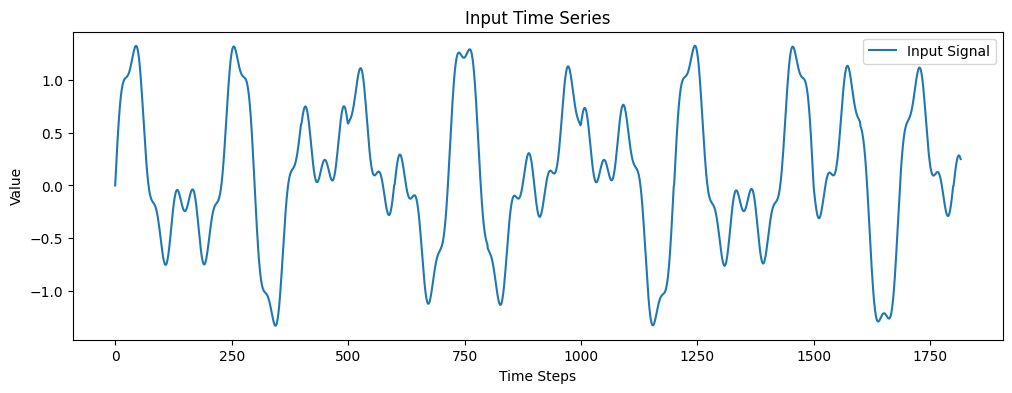

In [312]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(signal, label="Input Signal")
ax.set_title("Input Time Series")
ax.set_xlabel("Time Steps")
ax.set_ylabel("Value")
ax.legend()
plt.show()

### Processing

In [313]:
CURRENT_STRIDE = 16
pipeline.model.patch.patch_stride = CURRENT_STRIDE

with torch.no_grad():

    with torch.no_grad():
        forecast = pipeline.predict(
            input,
            prediction_length=11,
        )

pred_median = forecast[0].median(dim=0).values.numpy()  # (64,)
print("Forecast shape (with 9 quantiles):", forecast.shape)
print("Median forecast shape:", pred_median.shape)

Forecast shape (with 9 quantiles): torch.Size([1, 9, 11])
Median forecast shape: (11,)


In [314]:
remove_hooks()

Removed all hooks. captured keys: ['normalized', 'patch', 'embedding_input', 'hidden', 'relu', 'output_linear', 'residual', 'final_embedding', 'encoder_block_0', 'encoder_block_1', 'encoder_block_2', 'encoder_block_3', 'encoder_output_layer', 'decoder_block_0', 'decoder_block_1', 'decoder_block_2', 'decoder_block_3', 'decoder_output_layer', 'final_input', 'final_hidden', 'final_relu', 'final_output', 'final_residual', 'final_model_output']


In [315]:
normalized = captured["normalized"]
patch = captured["patch"]
embedding_input = captured["embedding_input"]
hidden = captured["hidden"]
relu = captured["relu"]
output_linear = captured["output_linear"]
residual = captured["residual"]
final_embedding = captured["final_embedding"]

encoder_block_0 = captured["encoder_block_0"]
encoder_block_1 = captured["encoder_block_1"]
encoder_block_2 = captured["encoder_block_2"]
encoder_block_3 = captured["encoder_block_3"]
encoder_output_layer = captured["encoder_output_layer"]

decoder_block_0 = captured["decoder_block_0"]
decoder_block_1 = captured["decoder_block_1"]
decoder_block_2 = captured["decoder_block_2"]
decoder_block_3 = captured["decoder_block_3"]
decoder_output_layer = captured["decoder_output_layer"]

final_input = captured["final_input"]
final_hidden = captured["final_hidden"]
final_relu = captured["final_relu"]
final_output = captured["final_output"]
final_residual = captured["final_residual"]
final_model_output = captured["final_model_output"]

In [316]:
remember = {}
def print_remember():
    for key, value in remember.items():
        if value is not None and key is not None:
            print(f"REMEMBER -- {key}: {value}")

In [317]:
print("\n================================================")
print("0. INPUT SERIES")
print("================================================")

input_shape = input.shape
print("Shape:", input_shape)

for i in range(input_shape[1]):
    print(f"Value {i}: {input[0, i].item()}")
    
remember["Input shape"] = input_shape


0. INPUT SERIES
Shape: torch.Size([1, 1816])
Value 0: 0.0
Value 1: 0.08690839260816574
Value 2: 0.17298011481761932
Value 3: 0.25739651918411255
Value 4: 0.3393746614456177
Value 5: 0.41818395256996155
Value 6: 0.4931616485118866
Value 7: 0.5637266635894775
Value 8: 0.6293914318084717
Value 9: 0.689771294593811
Value 10: 0.7445917725563049
Value 11: 0.7936927676200867
Value 12: 0.8370300531387329
Value 13: 0.874674379825592
Value 14: 0.9068070650100708
Value 15: 0.9337137341499329
Value 16: 0.95577472448349
Value 17: 0.9734541177749634
Value 18: 0.9872859120368958
Value 19: 0.9978592991828918
Value 20: 1.0058019161224365
Value 21: 1.011763334274292
Value 22: 1.0163965225219727
Value 23: 1.020341157913208
Value 24: 1.0242059230804443
Value 25: 1.0285524129867554
Value 26: 1.0338801145553589
Value 27: 1.040612816810608
Value 28: 1.0490878820419312
Value 29: 1.0595463514328003
Value 30: 1.072127103805542
Value 31: 1.086862325668335
Value 32: 1.1036767959594727
Value 33: 1.122389197349548

In [318]:
print_remember()
print("\n================================================")
print("1. NORMALIZED SERIES")
print("================================================")

if isinstance(normalized, tuple):
    normalized_values, normalized_stats = normalized
    normalized = normalized_values  # keep the rest of the cell compatible

norm_shape = normalized.shape
print("Shape:", norm_shape)

for i in range(norm_shape[1]):
    print(f"\nNormalized Value {i}:")
    print(normalized[0, i])

remember["Normalized shape"] = norm_shape

REMEMBER -- Input shape: torch.Size([1, 1816])

1. NORMALIZED SERIES
Shape: torch.Size([1, 1816])

Normalized Value 0:
tensor(-0.1533)

Normalized Value 1:
tensor(-0.0245)

Normalized Value 2:
tensor(0.1031)

Normalized Value 3:
tensor(0.2282)

Normalized Value 4:
tensor(0.3497)

Normalized Value 5:
tensor(0.4665)

Normalized Value 6:
tensor(0.5776)

Normalized Value 7:
tensor(0.6822)

Normalized Value 8:
tensor(0.7795)

Normalized Value 9:
tensor(0.8690)

Normalized Value 10:
tensor(0.9503)

Normalized Value 11:
tensor(1.0230)

Normalized Value 12:
tensor(1.0873)

Normalized Value 13:
tensor(1.1431)

Normalized Value 14:
tensor(1.1907)

Normalized Value 15:
tensor(1.2306)

Normalized Value 16:
tensor(1.2633)

Normalized Value 17:
tensor(1.2895)

Normalized Value 18:
tensor(1.3100)

Normalized Value 19:
tensor(1.3256)

Normalized Value 20:
tensor(1.3374)

Normalized Value 21:
tensor(1.3462)

Normalized Value 22:
tensor(1.3531)

Normalized Value 23:
tensor(1.3589)

Normalized Value 24:


In [319]:
print_remember()
print("\n================================================")
print("2. PATCH MODULE OUTPUT")
print("================================================")

patch_shape = patch.shape
print("Shape:", patch_shape)

for i in range(patch_shape[1]):
    print(f"\nPatch {i}:")
    print(patch[0, i])

remember["Patch shape"] = patch_shape

REMEMBER -- Input shape: torch.Size([1, 1816])
REMEMBER -- Normalized shape: torch.Size([1, 1816])

2. PATCH MODULE OUTPUT
Shape: torch.Size([1, 114, 16])

Patch 0:
tensor([nan, nan, nan, nan, nan, nan, nan, nan, 1., 1., 1., 1., 1., 1., 1., 1.])

Patch 1:
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

Patch 2:
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

Patch 3:
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

Patch 4:
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

Patch 5:
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

Patch 6:
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

Patch 7:
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

Patch 8:
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

Patch 9:
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

Patch 

In [320]:
print_remember()
print("\n================================================")
print("3. EMBEDDING INPUT")
print("================================================")

embedding_input_shape = embedding_input.shape
print("Shape:", embedding_input_shape)

for i in range(embedding_input_shape[1]):
    print(f"\nEmbedding Input {i}:")
    print(embedding_input[0, i])

remember["Embedding Input shape"] = embedding_input_shape

REMEMBER -- Input shape: torch.Size([1, 1816])
REMEMBER -- Normalized shape: torch.Size([1, 1816])
REMEMBER -- Patch shape: torch.Size([1, 114, 16])

3. EMBEDDING INPUT
Shape: torch.Size([1, 114, 32])

Embedding Input 0:
tensor([ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
        -0.1533, -0.0245,  0.1031,  0.2282,  0.3497,  0.4665,  0.5776,  0.6822,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000])

Embedding Input 1:
tensor([0.7795, 0.8690, 0.9503, 1.0230, 1.0873, 1.1431, 1.1907, 1.2306, 1.2633,
        1.2895, 1.3100, 1.3256, 1.3374, 1.3462, 1.3531, 1.3589, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

Embedding Input 2:
tensor([1.3647, 1.3711, 1.3790, 1.3890, 1.4016, 1.4171, 1.4357, 1.4575, 1.4825,
        1.5102, 1.5403, 1.5723, 1.6054, 1.6389, 1

In [321]:
print_remember()
print("\n================================================")
print("4. HIDDEN FEATURES")
print("================================================")

hidden_shape = hidden.shape
print("Shape:", hidden_shape)

for i in range(hidden_shape[1]):
    print(f"\nHidden Feature {i}:")
    print(hidden[0, i])

remember["Hidden shape"] = hidden_shape

REMEMBER -- Input shape: torch.Size([1, 1816])
REMEMBER -- Normalized shape: torch.Size([1, 1816])
REMEMBER -- Patch shape: torch.Size([1, 114, 16])
REMEMBER -- Embedding Input shape: torch.Size([1, 114, 32])

4. HIDDEN FEATURES
Shape: torch.Size([1, 114, 1024])

Hidden Feature 0:
tensor([-0.3138, -0.4247, -0.3834,  ..., -0.3834, -0.7747, -0.4014])

Hidden Feature 1:
tensor([-0.3138, -0.4247, -0.3834,  ..., -0.3834, -0.8039, -0.4014])

Hidden Feature 2:
tensor([-0.3138, -0.4247, -0.3834,  ..., -0.3834, -0.8054, -0.4014])

Hidden Feature 3:
tensor([-0.3138, -0.4247, -0.3834,  ..., -0.3834, -0.8079, -0.4014])

Hidden Feature 4:
tensor([-0.3138, -0.4247, -0.3834,  ..., -0.3834, -0.7977, -0.4014])

Hidden Feature 5:
tensor([-0.3138, -0.4247, -0.3834,  ..., -0.3834, -0.7909, -0.4014])

Hidden Feature 6:
tensor([-0.3138, -0.4247, -0.3834,  ..., -0.3834, -0.7878, -0.4014])

Hidden Feature 7:
tensor([-0.3138, -0.4247, -0.3834,  ..., -0.3834, -0.7842, -0.4014])

Hidden Feature 8:
tensor([-0.313

In [322]:
print_remember()
print("\n================================================")
print("5. RELU ACTIVATIONS")
print("================================================")

relu_shape = relu.shape
print("Shape:", relu_shape)

for i in range(relu_shape[1]):
    print(f"\nReLU Activation {i}:")
    print(relu[0, i])

remember["ReLU shape"] = relu_shape

REMEMBER -- Input shape: torch.Size([1, 1816])
REMEMBER -- Normalized shape: torch.Size([1, 1816])
REMEMBER -- Patch shape: torch.Size([1, 114, 16])
REMEMBER -- Embedding Input shape: torch.Size([1, 114, 32])
REMEMBER -- Hidden shape: torch.Size([1, 114, 1024])

5. RELU ACTIVATIONS
Shape: torch.Size([1, 114, 1024])

ReLU Activation 0:
tensor([0., 0., 0.,  ..., 0., 0., 0.])

ReLU Activation 1:
tensor([0., 0., 0.,  ..., 0., 0., 0.])

ReLU Activation 2:
tensor([0., 0., 0.,  ..., 0., 0., 0.])

ReLU Activation 3:
tensor([0., 0., 0.,  ..., 0., 0., 0.])

ReLU Activation 4:
tensor([0., 0., 0.,  ..., 0., 0., 0.])

ReLU Activation 5:
tensor([0., 0., 0.,  ..., 0., 0., 0.])

ReLU Activation 6:
tensor([0., 0., 0.,  ..., 0., 0., 0.])

ReLU Activation 7:
tensor([0., 0., 0.,  ..., 0., 0., 0.])

ReLU Activation 8:
tensor([0., 0., 0.,  ..., 0., 0., 0.])

ReLU Activation 9:
tensor([0., 0., 0.,  ..., 0., 0., 0.])

ReLU Activation 10:
tensor([0., 0., 0.,  ..., 0., 0., 0.])

ReLU Activation 11:
tensor([0., 

In [323]:
print_remember()
print("\n================================================")
print("6. OUTPUT LINEAR")
print("================================================")

output_linear_shape = output_linear.shape
print("Shape:", output_linear.shape)
    
for i in range(output_linear.shape[1]):
    print(f"\nOutput Linear {i}:")
    print(output_linear[0, i])

remember["Output Linear shape"] = output_linear_shape

REMEMBER -- Input shape: torch.Size([1, 1816])
REMEMBER -- Normalized shape: torch.Size([1, 1816])
REMEMBER -- Patch shape: torch.Size([1, 114, 16])
REMEMBER -- Embedding Input shape: torch.Size([1, 114, 32])
REMEMBER -- Hidden shape: torch.Size([1, 114, 1024])
REMEMBER -- ReLU shape: torch.Size([1, 114, 1024])

6. OUTPUT LINEAR
Shape: torch.Size([1, 114, 256])

Output Linear 0:
tensor([-1.0771e-02,  3.0544e-02,  2.8175e-02, -2.1960e-02,  2.5906e-02,
         3.2693e-03, -6.8324e-02,  2.2913e-02, -3.8983e-02, -5.5389e-02,
        -1.8765e-02,  5.9013e-02, -2.4859e-01, -3.5058e-02, -3.8023e-03,
         2.5285e-02,  4.5089e-02,  4.4377e-02, -1.5311e-02,  6.4488e-03,
         7.5033e-02,  2.4103e-02,  2.2655e-02,  3.3567e-02, -1.3549e-02,
         8.0948e-02, -2.2843e-03, -4.3817e-02,  7.8933e-02,  9.7981e-03,
         2.5648e-02,  8.9316e-03,  4.3853e-02,  3.2632e-02, -5.6311e-02,
         1.8919e-02,  4.9456e-02, -3.7565e-03,  1.8541e-02,  1.8567e-02,
        -3.0194e-02, -9.4876e-02, 

In [324]:
print_remember()
print("\n================================================")
print("7. RESIDUAL PATHWAY")
print("================================================")

residual_shape = residual.shape
print("Shape:", residual.shape)

for i in range(residual.shape[1]):
    print(f"\nResidual {i}:")
    print(residual[0, i])

remember["Residual shape"] = residual_shape

REMEMBER -- Input shape: torch.Size([1, 1816])
REMEMBER -- Normalized shape: torch.Size([1, 1816])
REMEMBER -- Patch shape: torch.Size([1, 114, 16])
REMEMBER -- Embedding Input shape: torch.Size([1, 114, 32])
REMEMBER -- Hidden shape: torch.Size([1, 114, 1024])
REMEMBER -- ReLU shape: torch.Size([1, 114, 1024])
REMEMBER -- Output Linear shape: torch.Size([1, 114, 256])

7. RESIDUAL PATHWAY
Shape: torch.Size([1, 114, 256])

Residual 0:
tensor([-4.0785e-02, -9.6138e-02,  4.3526e-02,  5.5297e-02, -5.1174e-02,
         1.8896e-02,  3.7928e-02, -3.3526e-02,  3.4075e-02,  6.2297e-02,
        -6.0162e-02, -1.4205e-01,  5.1280e-01,  1.3504e-02, -5.5174e-02,
        -1.1486e-02, -6.9455e-02, -8.2146e-03, -1.6440e-02,  6.3694e-02,
        -1.6870e-01, -3.9080e-02, -9.2072e-02, -8.3116e-02,  2.0567e-02,
        -1.0457e-01,  2.5287e-02,  5.7574e-02, -1.4156e-01,  2.9827e-02,
         3.0571e-02, -3.4775e-02,  3.7063e-02, -5.3547e-03,  2.1404e-02,
        -6.4773e-04, -3.8650e-02,  2.5981e-02, -2.

In [325]:
print_remember()
print("\n================================================")
print("8. FINAL PATCH EMBEDDINGS")
print("================================================")

final_embedding_shape = final_embedding.shape
print("Shape:", final_embedding_shape)

batch, num_patches, d_model = final_embedding_shape
for i in range(num_patches):
    print(f"\nFinal Embedding {i}:")
    print(final_embedding[0, i])

remember["Final Embedding shape"] = final_embedding_shape

REMEMBER -- Input shape: torch.Size([1, 1816])
REMEMBER -- Normalized shape: torch.Size([1, 1816])
REMEMBER -- Patch shape: torch.Size([1, 114, 16])
REMEMBER -- Embedding Input shape: torch.Size([1, 114, 32])
REMEMBER -- Hidden shape: torch.Size([1, 114, 1024])
REMEMBER -- ReLU shape: torch.Size([1, 114, 1024])
REMEMBER -- Output Linear shape: torch.Size([1, 114, 256])
REMEMBER -- Residual shape: torch.Size([1, 114, 256])

8. FINAL PATCH EMBEDDINGS
Shape: torch.Size([1, 114, 256])

Final Embedding 0:
tensor([-5.1556e-02, -6.5593e-02,  7.1700e-02,  3.3338e-02, -2.5268e-02,
         2.2165e-02, -3.0396e-02, -1.0613e-02, -4.9079e-03,  6.9077e-03,
        -7.8927e-02, -8.3035e-02,  2.6421e-01, -2.1554e-02, -5.8976e-02,
         1.3798e-02, -2.4366e-02,  3.6162e-02, -3.1752e-02,  7.0143e-02,
        -9.3663e-02, -1.4977e-02, -6.9416e-02, -4.9549e-02,  7.0181e-03,
        -2.3624e-02,  2.3003e-02,  1.3756e-02, -6.2632e-02,  3.9625e-02,
         5.6220e-02, -2.5843e-02,  8.0916e-02,  2.7278e-

In [326]:
print_remember()
print("\n================================================")
print("9. ENCODER HIDDEN STATES (0-1-2-3 BLOCKS)")
print("================================================")

encoder_block_0_shape = encoder_block_0.shape
print("Shape 0:", encoder_block_0_shape)
encoder_block_1_shape = encoder_block_1.shape
print("Shape 1:", encoder_block_1_shape)
encoder_block_2_shape = encoder_block_2.shape
print("Shape 2:", encoder_block_2_shape)
encoder_block_3_shape = encoder_block_3.shape
print("Shape 3:", encoder_block_3_shape)
print("Remember +1 in size[1] because of the CLS token added at the beginning of the sequence")

for i in range(encoder_block_0_shape[1]):
    print(f"\nEncoder Block 0 - Hidden State {i}:")
    print(encoder_block_0[0, i])
remember["Encoder Block 0 shape"] = encoder_block_0_shape
for i in range(encoder_block_1_shape[1]):
    print(f"\nEncoder Block 1 - Hidden State {i}:")
    print(encoder_block_1[0, i])
remember["Encoder Block 1 shape"] = encoder_block_1_shape
for i in range(encoder_block_2_shape[1]):
    print(f"\nEncoder Block 2 - Hidden State {i}:")
    print(encoder_block_2[0, i])
remember["Encoder Block 2 shape"] = encoder_block_2_shape
for i in range(encoder_block_3_shape[1]):
    print(f"\nEncoder Block 3 - Hidden State {i}:")
    print(encoder_block_3[0, i])
remember["Encoder Block 3 shape"] = encoder_block_3_shape

REMEMBER -- Input shape: torch.Size([1, 1816])
REMEMBER -- Normalized shape: torch.Size([1, 1816])
REMEMBER -- Patch shape: torch.Size([1, 114, 16])
REMEMBER -- Embedding Input shape: torch.Size([1, 114, 32])
REMEMBER -- Hidden shape: torch.Size([1, 114, 1024])
REMEMBER -- ReLU shape: torch.Size([1, 114, 1024])
REMEMBER -- Output Linear shape: torch.Size([1, 114, 256])
REMEMBER -- Residual shape: torch.Size([1, 114, 256])
REMEMBER -- Final Embedding shape: torch.Size([1, 114, 256])

9. ENCODER HIDDEN STATES (0-1-2-3 BLOCKS)
Shape 0: torch.Size([1, 115, 256])
Shape 1: torch.Size([1, 115, 256])
Shape 2: torch.Size([1, 115, 256])
Shape 3: torch.Size([1, 115, 256])
Remember +1 in size[1] because of the CLS token added at the beginning of the sequence

Encoder Block 0 - Hidden State 0:
tensor([-5.9667e-02, -1.3444e-01,  7.6439e-02,  8.6014e-02, -8.3217e-02,
         1.9061e-02, -6.7903e-02,  2.7797e-02,  3.0091e-02,  4.1666e-02,
        -1.2332e-01, -7.9738e-02,  1.5939e-01, -3.0989e-02, -7

In [327]:
print_remember()
print("\n================================================")
print("9. ENCODER OUTPUT LAYER")
print("================================================")

encoder_output_shape = encoder_output_layer.shape
print("Shape:", encoder_output_shape)

for i in range(encoder_output_shape[1]):
    print(f"\nEncoder Output Layer {i}:")
    print(encoder_output_layer[0, i])
remember["Encoder Output Layer shape"] = encoder_output_shape

REMEMBER -- Input shape: torch.Size([1, 1816])
REMEMBER -- Normalized shape: torch.Size([1, 1816])
REMEMBER -- Patch shape: torch.Size([1, 114, 16])
REMEMBER -- Embedding Input shape: torch.Size([1, 114, 32])
REMEMBER -- Hidden shape: torch.Size([1, 114, 1024])
REMEMBER -- ReLU shape: torch.Size([1, 114, 1024])
REMEMBER -- Output Linear shape: torch.Size([1, 114, 256])
REMEMBER -- Residual shape: torch.Size([1, 114, 256])
REMEMBER -- Final Embedding shape: torch.Size([1, 114, 256])
REMEMBER -- Encoder Block 0 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Block 1 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Block 2 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Block 3 shape: torch.Size([1, 115, 256])

9. ENCODER OUTPUT LAYER
Shape: torch.Size([1, 115, 256])

Encoder Output Layer 0:
tensor([-3.9088e-01, -2.1136e-01,  3.1358e-02,  4.0583e-01, -1.3776e+00,
         4.7741e-02,  4.8387e-02,  4.4842e-02, -4.2300e-01,  3.5484e-01,
        -4.9245e-01, -5.7391e-01, -8.073

In [ ]:
print_remember()
print("\n================================================")
print("9. DECODER HIDDEN STATES")
print("================================================")

decoder_block_0_shape = decoder_block_0.shape
print("Shape 0:", decoder_block_0_shape)
decoder_block_1_shape = decoder_block_1.shape
print("Shape 1:", decoder_block_1_shape)
decoder_block_2_shape = decoder_block_2.shape
print("Shape 2:", decoder_block_2_shape)
decoder_block_3_shape = decoder_block_3.shape
print("Shape 3:", decoder_block_3_shape)

for i in range(decoder_block_0_shape[1]):
    print(f"\nDecoder Block 0 - Hidden State {i}:")
    print(decoder_block_0[0, i])
remember["Decoder Block 0 shape"] = decoder_block_0_shape
for i in range(decoder_block_1_shape[1]):
    print(f"\nDecoder Block 1 - Hidden State {i}:")
    print(decoder_block_1[0, i])
remember["Decoder Block 1 shape"] = decoder_block_1_shape
for i in range(decoder_block_2_shape[1]):
    print(f"\nDecoder Block 2 - Hidden State {i}:")
    print(decoder_block_2[0, i])
remember["Decoder Block 2 shape"] = decoder_block_2_shape
for i in range(decoder_block_3_shape[1]):
    print(f"\nDecoder Block 3 - Hidden State {i}:")
    print(decoder_block_3[0, i])
remember["Decoder Block 3 shape"] = decoder_block_3_shape


REMEMBER -- Input shape: torch.Size([1, 1816])
REMEMBER -- Normalized shape: torch.Size([1, 1816])
REMEMBER -- Patch shape: torch.Size([1, 114, 16])
REMEMBER -- Embedding Input shape: torch.Size([1, 114, 32])
REMEMBER -- Hidden shape: torch.Size([1, 114, 1024])
REMEMBER -- ReLU shape: torch.Size([1, 114, 1024])
REMEMBER -- Output Linear shape: torch.Size([1, 114, 256])
REMEMBER -- Residual shape: torch.Size([1, 114, 256])
REMEMBER -- Final Embedding shape: torch.Size([1, 114, 256])
REMEMBER -- Encoder Block 0 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Block 1 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Block 2 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Block 3 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Output Layer shape: torch.Size([1, 115, 256])

9. DECODER HIDDEN STATES
Shape 0: torch.Size([1, 1, 256])
Shape 1: torch.Size([1, 1, 256])
Shape 2: torch.Size([1, 1, 256])
Shape 3: torch.Size([1, 1, 256])
Remember +1 in size[1] because of the CLS tok

In [329]:
print_remember()
print("\n================================================")
print("9. DECODER OUTPUT LAYER")
print("================================================")


decoder_output_shape = decoder_output_layer.shape
print("Shape:", decoder_output_shape)

for i in range(decoder_output_shape[1]):
    print(f"\nDecoder Output Layer {i}:")
    print(decoder_output_layer[0, i])
remember["Decoder Output Layer shape"] = decoder_output_shape

REMEMBER -- Input shape: torch.Size([1, 1816])
REMEMBER -- Normalized shape: torch.Size([1, 1816])
REMEMBER -- Patch shape: torch.Size([1, 114, 16])
REMEMBER -- Embedding Input shape: torch.Size([1, 114, 32])
REMEMBER -- Hidden shape: torch.Size([1, 114, 1024])
REMEMBER -- ReLU shape: torch.Size([1, 114, 1024])
REMEMBER -- Output Linear shape: torch.Size([1, 114, 256])
REMEMBER -- Residual shape: torch.Size([1, 114, 256])
REMEMBER -- Final Embedding shape: torch.Size([1, 114, 256])
REMEMBER -- Encoder Block 0 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Block 1 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Block 2 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Block 3 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Output Layer shape: torch.Size([1, 115, 256])
REMEMBER -- Decoder Block 0 shape: torch.Size([1, 1, 256])
REMEMBER -- Decoder Block 1 shape: torch.Size([1, 1, 256])
REMEMBER -- Decoder Block 2 shape: torch.Size([1, 1, 256])
REMEMBER -- Decoder Block 

In [330]:
print_remember()
print("\n================================================")
print("9. FINAL INPUT")
print("================================================")

final_input_shape = final_input.shape
print("Shape:", final_input_shape)

for i in range(final_input_shape[1]):
    print(f"\nFinal Input {i}:")
    print(final_input[0, i])
remember["Final Input shape"] = final_input_shape


REMEMBER -- Input shape: torch.Size([1, 1816])
REMEMBER -- Normalized shape: torch.Size([1, 1816])
REMEMBER -- Patch shape: torch.Size([1, 114, 16])
REMEMBER -- Embedding Input shape: torch.Size([1, 114, 32])
REMEMBER -- Hidden shape: torch.Size([1, 114, 1024])
REMEMBER -- ReLU shape: torch.Size([1, 114, 1024])
REMEMBER -- Output Linear shape: torch.Size([1, 114, 256])
REMEMBER -- Residual shape: torch.Size([1, 114, 256])
REMEMBER -- Final Embedding shape: torch.Size([1, 114, 256])
REMEMBER -- Encoder Block 0 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Block 1 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Block 2 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Block 3 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Output Layer shape: torch.Size([1, 115, 256])
REMEMBER -- Decoder Block 0 shape: torch.Size([1, 1, 256])
REMEMBER -- Decoder Block 1 shape: torch.Size([1, 1, 256])
REMEMBER -- Decoder Block 2 shape: torch.Size([1, 1, 256])
REMEMBER -- Decoder Block 

In [331]:
print_remember()
print("\n================================================")
print("9. FINAL HIDDEN")
print("================================================")

final_hidden_shape = final_hidden.shape
print("Shape:", final_hidden_shape)

for i in range(final_hidden_shape[1]):
    print(f"\nFinal Hidden {i}:")
    print(final_hidden[0, i])
remember["Final Hidden shape"] = final_hidden_shape

REMEMBER -- Input shape: torch.Size([1, 1816])
REMEMBER -- Normalized shape: torch.Size([1, 1816])
REMEMBER -- Patch shape: torch.Size([1, 114, 16])
REMEMBER -- Embedding Input shape: torch.Size([1, 114, 32])
REMEMBER -- Hidden shape: torch.Size([1, 114, 1024])
REMEMBER -- ReLU shape: torch.Size([1, 114, 1024])
REMEMBER -- Output Linear shape: torch.Size([1, 114, 256])
REMEMBER -- Residual shape: torch.Size([1, 114, 256])
REMEMBER -- Final Embedding shape: torch.Size([1, 114, 256])
REMEMBER -- Encoder Block 0 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Block 1 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Block 2 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Block 3 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Output Layer shape: torch.Size([1, 115, 256])
REMEMBER -- Decoder Block 0 shape: torch.Size([1, 1, 256])
REMEMBER -- Decoder Block 1 shape: torch.Size([1, 1, 256])
REMEMBER -- Decoder Block 2 shape: torch.Size([1, 1, 256])
REMEMBER -- Decoder Block 

In [332]:
print_remember()
print("\n================================================")
print("9. FINAL RELU")
print("================================================")

final_relu_shape = final_relu.shape
print("Shape:", final_relu_shape)

for i in range(final_relu_shape[1]):
    print(f"\nFinal ReLU {i}:")
    print(final_relu[0, i])
remember["Final ReLU shape"] = final_relu_shape

REMEMBER -- Input shape: torch.Size([1, 1816])
REMEMBER -- Normalized shape: torch.Size([1, 1816])
REMEMBER -- Patch shape: torch.Size([1, 114, 16])
REMEMBER -- Embedding Input shape: torch.Size([1, 114, 32])
REMEMBER -- Hidden shape: torch.Size([1, 114, 1024])
REMEMBER -- ReLU shape: torch.Size([1, 114, 1024])
REMEMBER -- Output Linear shape: torch.Size([1, 114, 256])
REMEMBER -- Residual shape: torch.Size([1, 114, 256])
REMEMBER -- Final Embedding shape: torch.Size([1, 114, 256])
REMEMBER -- Encoder Block 0 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Block 1 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Block 2 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Block 3 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Output Layer shape: torch.Size([1, 115, 256])
REMEMBER -- Decoder Block 0 shape: torch.Size([1, 1, 256])
REMEMBER -- Decoder Block 1 shape: torch.Size([1, 1, 256])
REMEMBER -- Decoder Block 2 shape: torch.Size([1, 1, 256])
REMEMBER -- Decoder Block 

In [333]:
print_remember()
print("\n================================================")
print("9. FINAL OUTPUT")
print("================================================")

final_output_shape = final_output.shape
print("Shape:", final_output_shape)

for i in range(final_output_shape[1]):
    print(f"\nFinal Output {i}:")
    print(final_output[0, i])
remember["Final Output shape"] = final_output_shape

REMEMBER -- Input shape: torch.Size([1, 1816])
REMEMBER -- Normalized shape: torch.Size([1, 1816])
REMEMBER -- Patch shape: torch.Size([1, 114, 16])
REMEMBER -- Embedding Input shape: torch.Size([1, 114, 32])
REMEMBER -- Hidden shape: torch.Size([1, 114, 1024])
REMEMBER -- ReLU shape: torch.Size([1, 114, 1024])
REMEMBER -- Output Linear shape: torch.Size([1, 114, 256])
REMEMBER -- Residual shape: torch.Size([1, 114, 256])
REMEMBER -- Final Embedding shape: torch.Size([1, 114, 256])
REMEMBER -- Encoder Block 0 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Block 1 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Block 2 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Block 3 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Output Layer shape: torch.Size([1, 115, 256])
REMEMBER -- Decoder Block 0 shape: torch.Size([1, 1, 256])
REMEMBER -- Decoder Block 1 shape: torch.Size([1, 1, 256])
REMEMBER -- Decoder Block 2 shape: torch.Size([1, 1, 256])
REMEMBER -- Decoder Block 

In [334]:
print_remember()
print("\n================================================")
print("9. FINAL RESIDUAL")
print("================================================")

final_residual_shape = final_residual.shape
print("Shape:", final_residual_shape)

for i in range(final_residual_shape[1]):
    print(f"\nFinal Residual {i}:")
    print(final_residual[0, i])
remember["Final Residual shape"] = final_residual_shape

REMEMBER -- Input shape: torch.Size([1, 1816])
REMEMBER -- Normalized shape: torch.Size([1, 1816])
REMEMBER -- Patch shape: torch.Size([1, 114, 16])
REMEMBER -- Embedding Input shape: torch.Size([1, 114, 32])
REMEMBER -- Hidden shape: torch.Size([1, 114, 1024])
REMEMBER -- ReLU shape: torch.Size([1, 114, 1024])
REMEMBER -- Output Linear shape: torch.Size([1, 114, 256])
REMEMBER -- Residual shape: torch.Size([1, 114, 256])
REMEMBER -- Final Embedding shape: torch.Size([1, 114, 256])
REMEMBER -- Encoder Block 0 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Block 1 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Block 2 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Block 3 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Output Layer shape: torch.Size([1, 115, 256])
REMEMBER -- Decoder Block 0 shape: torch.Size([1, 1, 256])
REMEMBER -- Decoder Block 1 shape: torch.Size([1, 1, 256])
REMEMBER -- Decoder Block 2 shape: torch.Size([1, 1, 256])
REMEMBER -- Decoder Block 

In [335]:
print_remember()
print("\n================================================")
print("9. FINAL MODEL OUTPUT")
print("================================================")

final_model_output_shape = final_model_output.shape
print("Shape:", final_model_output_shape)

for i in range(final_model_output_shape[1]):
    print(f"\nFinal Model Output {i}:")
    print(final_model_output[0, i])
remember["Final Model Output shape"] = final_model_output_shape

REMEMBER -- Input shape: torch.Size([1, 1816])
REMEMBER -- Normalized shape: torch.Size([1, 1816])
REMEMBER -- Patch shape: torch.Size([1, 114, 16])
REMEMBER -- Embedding Input shape: torch.Size([1, 114, 32])
REMEMBER -- Hidden shape: torch.Size([1, 114, 1024])
REMEMBER -- ReLU shape: torch.Size([1, 114, 1024])
REMEMBER -- Output Linear shape: torch.Size([1, 114, 256])
REMEMBER -- Residual shape: torch.Size([1, 114, 256])
REMEMBER -- Final Embedding shape: torch.Size([1, 114, 256])
REMEMBER -- Encoder Block 0 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Block 1 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Block 2 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Block 3 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Output Layer shape: torch.Size([1, 115, 256])
REMEMBER -- Decoder Block 0 shape: torch.Size([1, 1, 256])
REMEMBER -- Decoder Block 1 shape: torch.Size([1, 1, 256])
REMEMBER -- Decoder Block 2 shape: torch.Size([1, 1, 256])
REMEMBER -- Decoder Block 

In [336]:
print_remember()
print("\n================================================")
print("FORECAST")
print("================================================")

forecast_shape = forecast.shape
print("Shape:", forecast_shape)
# the forecast shape is (batch_size, prediction_length, num_features), 
# where num_features is 1 for univariate forecasting. 
# So we can print the forecast as a list of values for each time step in the forecast horizon.

print("\nForecast:" )
print(forecast)

remember["Forecast shape"] = forecast_shape

REMEMBER -- Input shape: torch.Size([1, 1816])
REMEMBER -- Normalized shape: torch.Size([1, 1816])
REMEMBER -- Patch shape: torch.Size([1, 114, 16])
REMEMBER -- Embedding Input shape: torch.Size([1, 114, 32])
REMEMBER -- Hidden shape: torch.Size([1, 114, 1024])
REMEMBER -- ReLU shape: torch.Size([1, 114, 1024])
REMEMBER -- Output Linear shape: torch.Size([1, 114, 256])
REMEMBER -- Residual shape: torch.Size([1, 114, 256])
REMEMBER -- Final Embedding shape: torch.Size([1, 114, 256])
REMEMBER -- Encoder Block 0 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Block 1 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Block 2 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Block 3 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Output Layer shape: torch.Size([1, 115, 256])
REMEMBER -- Decoder Block 0 shape: torch.Size([1, 1, 256])
REMEMBER -- Decoder Block 1 shape: torch.Size([1, 1, 256])
REMEMBER -- Decoder Block 2 shape: torch.Size([1, 1, 256])
REMEMBER -- Decoder Block 

In [337]:
print_remember()

REMEMBER -- Input shape: torch.Size([1, 1816])
REMEMBER -- Normalized shape: torch.Size([1, 1816])
REMEMBER -- Patch shape: torch.Size([1, 114, 16])
REMEMBER -- Embedding Input shape: torch.Size([1, 114, 32])
REMEMBER -- Hidden shape: torch.Size([1, 114, 1024])
REMEMBER -- ReLU shape: torch.Size([1, 114, 1024])
REMEMBER -- Output Linear shape: torch.Size([1, 114, 256])
REMEMBER -- Residual shape: torch.Size([1, 114, 256])
REMEMBER -- Final Embedding shape: torch.Size([1, 114, 256])
REMEMBER -- Encoder Block 0 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Block 1 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Block 2 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Block 3 shape: torch.Size([1, 115, 256])
REMEMBER -- Encoder Output Layer shape: torch.Size([1, 115, 256])
REMEMBER -- Decoder Block 0 shape: torch.Size([1, 1, 256])
REMEMBER -- Decoder Block 1 shape: torch.Size([1, 1, 256])
REMEMBER -- Decoder Block 2 shape: torch.Size([1, 1, 256])
REMEMBER -- Decoder Block 

### Stats

In [338]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import os


X = final_embedding[0].detach().cpu().numpy()
n = X.shape[0]
idx = np.arange(n)

norms           = np.linalg.norm(X, axis=1)
sim_matrix      = cosine_similarity(X)
nonlinear_norm  = torch.norm(output_linear[0], dim=-1).detach().cpu().numpy()
residual_norm   = torch.norm(residual[0], dim=-1).detach().cpu().numpy()
hidden_pos_ratio   = (hidden[0] > 0).float().mean(dim=-1).numpy()
relu_nonzero_ratio = (relu[0] > 0).float().mean(dim=-1).numpy()

adjacent = [
    np.dot(X[i], X[i+1]) / (np.linalg.norm(X[i]) * np.linalg.norm(X[i+1]))
    for i in range(n - 1)
]

if n >= 3:
    Y = PCA(n_components=2).fit_transform(X)
    use_pca2d = True
else:
    x_c = X - X.mean(axis=0, keepdims=True)
    _, _, vt = np.linalg.svd(x_c, full_matrices=False)
    pc1 = x_c @ vt[0]
    use_pca2d = False

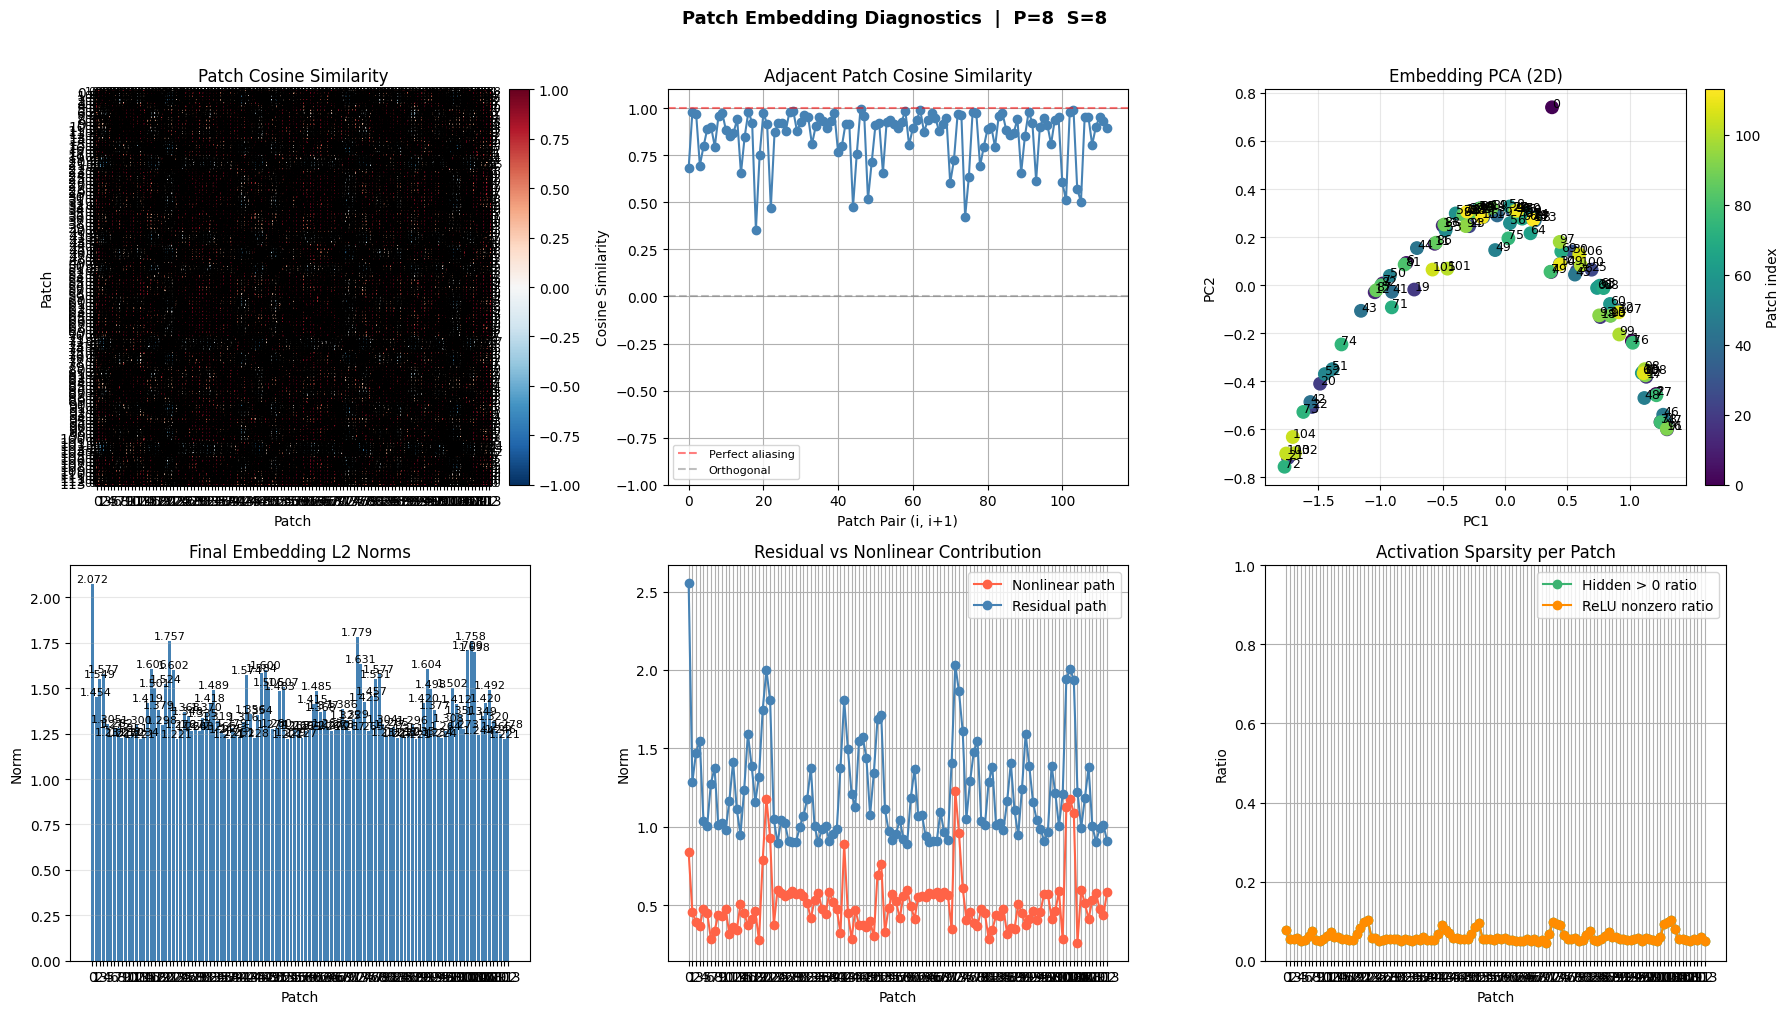

In [339]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ── 0,0 — Cosine similarity heatmap (core aliasing evidence)
ax = axes[0, 0]
im = ax.imshow(sim_matrix, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_title("Patch Cosine Similarity")
ax.set_xlabel("Patch")
ax.set_ylabel("Patch")
ax.set_xticks(idx)
ax.set_yticks(idx)
for r in range(n):
    for c in range(n):
        ax.text(c, r, f"{sim_matrix[r, c]:.2f}",
                ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# ── 0,1 — Adjacent cosine similarity (aliasing over time)
ax = axes[0, 1]
ax.plot(adjacent, marker="o", color="steelblue")
ax.axhline(y=1.0, color="red", linestyle="--", alpha=0.5, label="Perfect aliasing")
ax.axhline(y=0.0, color="gray", linestyle="--", alpha=0.5, label="Orthogonal")
ax.set_title("Adjacent Patch Cosine Similarity")
ax.set_xlabel("Patch Pair (i, i+1)")
ax.set_ylabel("Cosine Similarity")
ax.set_ylim(-1, 1.1)
ax.legend(fontsize=8)
ax.grid(True)

# ── 0,2 — PCA (geometry of embedding space)
ax = axes[0, 2]
if use_pca2d:
    sc = ax.scatter(Y[:, 0], Y[:, 1], c=idx, cmap="viridis", s=80, zorder=3)
    for k in range(n):
        ax.text(Y[k, 0], Y[k, 1], str(k), fontsize=9, ha="left")
    ax.set_title("Embedding PCA (2D)")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    fig.colorbar(sc, ax=ax, label="Patch index", fraction=0.046, pad=0.04)
else:
    ax.scatter(idx, pc1, c=idx, cmap="viridis", s=80)
    for k in range(n):
        ax.text(k, pc1[k], str(k), fontsize=9)
    ax.set_title("Embedding Projection on PC1")
    ax.set_xlabel("Patch")
    ax.set_ylabel("PC1 score")
    ax.set_xticks(idx)
ax.grid(alpha=0.3)

# ── 1,0 — L2 norms (do patches collapse to same magnitude?)
ax = axes[1, 0]
bars = ax.bar(idx, norms, color="steelblue")
ax.set_title("Final Embedding L2 Norms")
ax.set_xlabel("Patch")
ax.set_ylabel("Norm")
ax.set_xticks(idx)
ax.grid(axis="y", alpha=0.3)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height(),
            f"{b.get_height():.3f}", ha="center", va="bottom", fontsize=8)

# ── 1,1 — Residual vs nonlinear (where does information flow?)
ax = axes[1, 1]
ax.plot(nonlinear_norm, label="Nonlinear path", marker="o", color="tomato")
ax.plot(residual_norm,  label="Residual path",  marker="o", color="steelblue")
ax.set_title("Residual vs Nonlinear Contribution")
ax.set_xlabel("Patch")
ax.set_ylabel("Norm")
ax.set_xticks(idx)
ax.legend()
ax.grid(True)

# ── 1,2 — Activation sparsity (are patches using the same neurons?)
ax = axes[1, 2]
ax.plot(hidden_pos_ratio,    label="Hidden > 0 ratio",    marker="o", color="mediumseagreen")
ax.plot(relu_nonzero_ratio,  label="ReLU nonzero ratio",  marker="o", color="darkorange")
ax.set_title("Activation Sparsity per Patch")
ax.set_xlabel("Patch")
ax.set_ylabel("Ratio")
ax.set_xticks(idx)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True)

# ============================================================
# SAVE
# ============================================================

plt.suptitle(f"Patch Embedding Diagnostics  |  P={PATCH_SIZE}  S={STRIDE}", 
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

path = os.path.join(img_path, f"diagnostics_stride{STRIDE}_patch{PATCH_SIZE}.png")
fig.savefig(path, dpi=300, bbox_inches="tight")